In [1]:
# Torch-only toy simulation + posterior means (CGB vs sharp-CGB)
import torch
from matplotlib import pyplot as plt

from cebmf_torch.cebnm.cov_gb_prior import cgb_posterior_means
from cebmf_torch.cebnm.cov_sharp_gb_prior import sharp_cgb_posterior_means

# -------------------------
# Repro + device
# -------------------------
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

# -------------------------
# Toy covariates and observations
# -------------------------
N, P = 2000, 1
X = torch.randn(N, P, device=device, dtype=dtype)

# simulate π0(x) from a linear rule then generate θ and x
w = torch.randn(P, device=device, dtype=dtype) * 0.7
logit = (X @ w) * 0.8
pi0_true = torch.sigmoid(logit).squeeze(-1)         # (N,)

z = (torch.rand(N, device=device) < pi0_true).float()  # 1 = spike

mu_true, omega = 2.0, 0.25
sigma_true = omega * mu_true

# truncated-normal (at 0) slab
slab = torch.normal(mean=torch.tensor(mu_true, device=device, dtype=dtype),
                    std=torch.tensor(sigma_true, device=device, dtype=dtype),
                    size=(N,))
slab = torch.clamp(slab, min=0.0)
theta = (1.0 - z) * slab

se = torch.full((N,), 0.5, device=device, dtype=dtype)
x = theta + torch.randn(N, device=device, dtype=dtype) * se

# -------------------------
# Fit posterior means
# -------------------------
# NOTE: these functions should accept torch Tensors; if they expect CPU, call .cpu()
res = cgb_posterior_means(X, x, se, n_epochs=50)
res_sharp = sharp_cgb_posterior_means(X, x, se, n_epochs=50)

# If results are dicts, adapt the keys below; otherwise assume they’re tensors 
 

[CGB] Epoch 10/50, Loss=2.1552, mu2=0.153, sigma2=1.789
[CGB] Epoch 20/50, Loss=2.1139, mu2=0.314, sigma2=1.641
[CGB] Epoch 30/50, Loss=2.0697, mu2=0.480, sigma2=1.491
[CGB] Epoch 40/50, Loss=2.0210, mu2=0.647, sigma2=1.353
[CGB] Epoch 50/50, Loss=1.9769, mu2=0.813, sigma2=1.230
[CGB] Epoch 10/50, Loss=4.2367, mu2=0.160, sigma2=0.259
[CGB] Epoch 20/50, Loss=3.8803, mu2=0.322, sigma2=0.219
[CGB] Epoch 30/50, Loss=3.5494, mu2=0.477, sigma2=0.195
[CGB] Epoch 40/50, Loss=3.2552, mu2=0.625, sigma2=0.200
[CGB] Epoch 50/50, Loss=2.9892, mu2=0.764, sigma2=0.173


In [2]:
res_sharp.pi

tensor([0.5706, 0.5689, 0.5909,  ..., 0.5909, 0.6065, 0.5910])

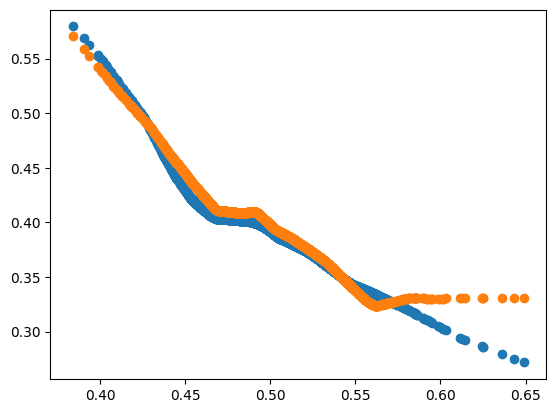

In [3]:
plt.scatter(pi0_true,1- res.pi )
plt.scatter(pi0_true, 1-res_sharp.pi )


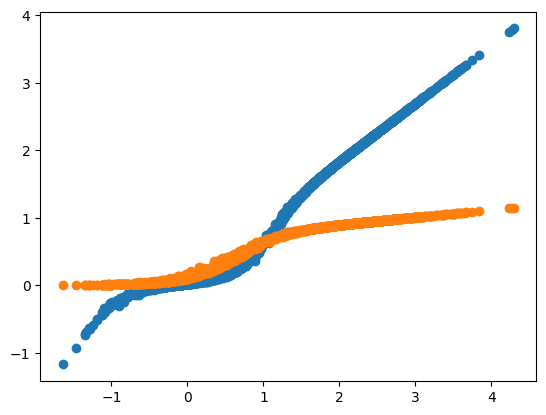

In [4]:
plt.scatter(x,res.post_mean )
plt.scatter(x,res_sharp.post_mean )

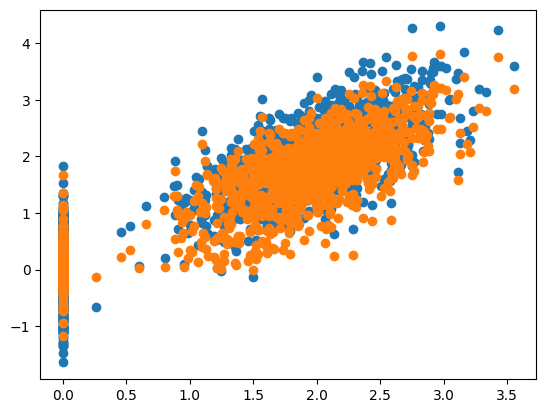

In [5]:
plt.scatter(theta,x)
plt.scatter(theta,res.post_mean)

In [6]:
res.loss

3451.07373046875

In [7]:
res_sharp.loss

5424.0859375